In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [3]:
X_xor = torch.tensor([[0.0, 0.0],
                      [0.0, 1.0],
                      [1.0, 0.0],
                      [1.0, 1.0]])

y_xor = torch.tensor([[0.0],
                      [1.0],
                      [1.0],
                      [0.0]])

In [ ]:
class XorNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.relu(self.hidden(x))
        # 시그모이드를 적용해서 결과를 0~1 사이로 압축합니다.
        x = torch.sigmoid(self.output(x)) 
        return x

# 1. 클래스 이름 대소문자 확인 (XorNet)
model = XorNet()

for p in model.parameters():
    print(f"학습 가능한 파라미터 수: {p.numel()}")



학습 가능한 파라미터 수: 8
학습 가능한 파라미터 수: 4
학습 가능한 파라미터 수: 4
학습 가능한 파라미터 수: 1


학습을 시작합니다...
Epoch [1000/5000], Loss: 0.0436
Epoch [2000/5000], Loss: 0.0093
Epoch [3000/5000], Loss: 0.0046
Epoch [4000/5000], Loss: 0.0030
Epoch [5000/5000], Loss: 0.0021
학습 완료!

[최종 모델 예측값]
tensor([[0.0022],
        [0.9987],
        [0.9969],
        [0.0019]])


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15236\240623845.py:81: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15236\240623845.py:81: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15236\240623845.py:81: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15236\240623845.py:81: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\mini\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\mini\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: 

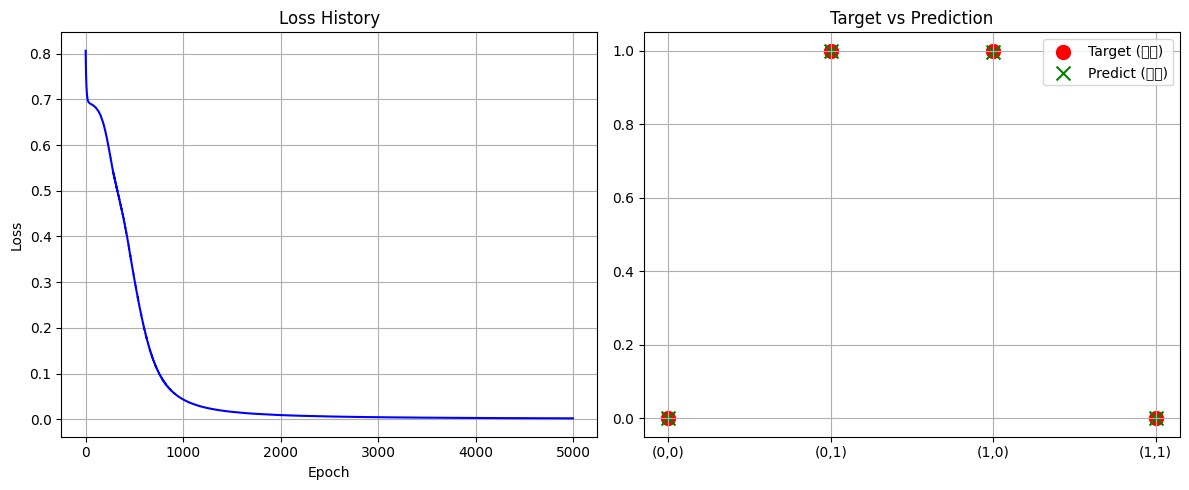

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. 시드 고정 (결과 재현성을 위해)
torch.manual_seed(42)

# 2. 데이터 정의 (XOR 문제)
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]])

# 3. 모델 정의 (간단한 신경망)
model = nn.Sequential(
    nn.Linear(2, 4),  # 입력 2 -> 은닉층 4 (노드 수를 조금 늘리면 학습이 더 잘 됩니다)
    nn.ReLU(),
    nn.Linear(4, 1),  # 은닉층 4 -> 출력 1
    nn.Sigmoid()
)

# 4. 손실 함수와 옵티마이저 설정
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 5. 학습 루프 (이미지 속 주석 목적 그대로 구현)
epochs = 5000
loss_history = []

print("학습을 시작합니다...")

for epoch in range(epochs):
    # (1) forward
    y_pred = model(X_xor)

    # (2) loss 계산
    loss = criterion(y_pred, y_xor)

    # (3) 기울기 초기화
    optimizer.zero_grad()

    # (4) 역전파 및 가중치 업데이트
    loss.backward()
    optimizer.step()

    # 시각화를 위해 손실 기록
    loss_history.append(loss.item())

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("학습 완료!\n")

# --- 6. 시각화 및 결과 확인 ---

# 시각화 설정 (2개 그래프 생성)
plt.figure(figsize=(12, 5))

# [그래프 1] 손실 변화량 (Learning Curve)
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='blue')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# [결과 확인] 모델의 최종 예측값 출력
print("[최종 모델 예측값]")
with torch.no_grad():
    final_pred = model(X_xor)
    print(final_pred)

# [그래프 2] 실제값 vs 예측값 비교 시각화
plt.subplot(1, 2, 2)
plt.scatter([0, 1, 2, 3], y_xor.flatten(), color='red', label='Target (정답)', s=100)
plt.scatter([0, 1, 2, 3], final_pred.flatten(), color='green', label='Predict (예측)', marker='x', s=100)
plt.title('Target vs Prediction')
plt.xticks([0, 1, 2, 3], ['(0,0)', '(0,1)', '(1,0)', '(1,1)'])
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">DataLoader 생성</span>

In [55]:
from sklearn.datasets import load_iris
import torch

# 데이터를 불러옵니다.
iris = load_iris()

# 데이터를 텐서로 변환합니다.
X = torch.tensor(iris.data, dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long)

In [56]:
train_dataset = TensorDataset(X,y)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

for data in train_loader:  # 1. 끝에 콜론(:) 추가
    print(data)            # 2. 들여쓰기 적용
    break                  # 3. 들여쓰기 적용

[tensor([[4.6000, 3.1000, 1.5000, 0.2000],
        [7.0000, 3.2000, 4.7000, 1.4000],
        [6.2000, 2.8000, 4.8000, 1.8000],
        [5.2000, 3.4000, 1.4000, 0.2000],
        [4.3000, 3.0000, 1.1000, 0.1000],
        [6.4000, 3.2000, 4.5000, 1.5000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [4.7000, 3.2000, 1.6000, 0.2000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.0000, 3.5000, 1.3000, 0.3000],
        [6.9000, 3.1000, 4.9000, 1.5000],
        [5.1000, 3.5000, 1.4000, 0.2000],
        [5.9000, 3.0000, 4.2000, 1.5000],
        [6.4000, 2.7000, 5.3000, 1.9000],
        [7.7000, 2.8000, 6.7000, 2.0000],
        [4.9000, 2.4000, 3.3000, 1.0000]]), tensor([0, 1, 2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 2, 2, 1])]


<span style="font-family: 'Gungsuh', '바탕체'; font-size: 2em; font-style: italic;">파이토치(PyTorch)를 이용한 붓꽃(Iris) 품종 분류 실습</span>

Epoch [20/100], Loss: 0.1162, Acc: 94.00%
Epoch [40/100], Loss: 0.0610, Acc: 97.33%
Epoch [60/100], Loss: 0.0599, Acc: 96.00%
Epoch [80/100], Loss: 0.0789, Acc: 96.67%
Epoch [100/100], Loss: 0.0582, Acc: 96.67%


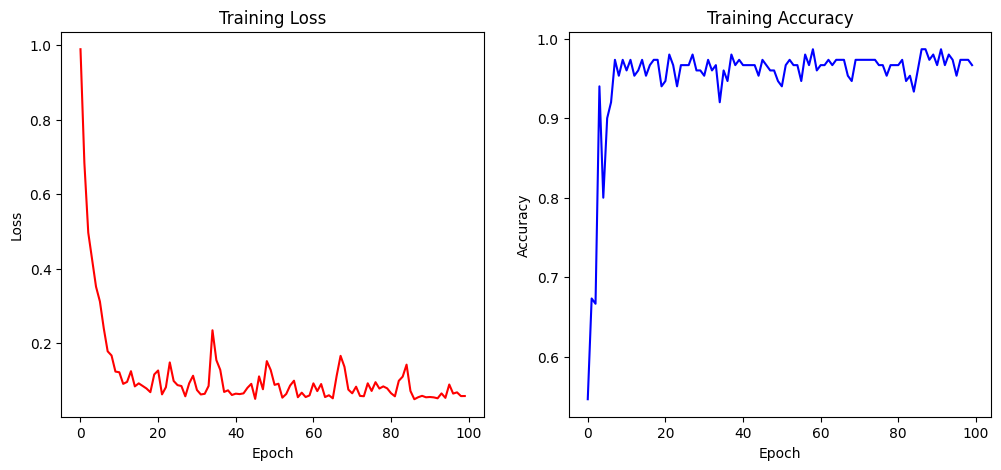


최종 학습 완료 후 정확도: 96.67%


In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# 1. 데이터 준비
iris = load_iris()
X = torch.tensor(iris.data, dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long)

dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

# 2. 모델 정의
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 3)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = IrisNet()

# 3. 손실함수 및 최적화 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
loss_graph = []
acc_graph = []  # 정확도를 저장할 리스트 추가

# 4. 학습 루프
for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    model.train() # 학습 모드
    for batch_X, batch_y in loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # --- 정확도 계산 로직 추가 ---
        # outputs: [16, 3] 형태의 텐서 (각 클래스별 확률값과 유사한 점수)
        # torch.max(outputs, 1) -> 가장 큰 값과 그 인덱스를 반환 (인덱스가 곧 예측 클래스)
        _, predicted = torch.max(outputs.data, 1) 
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
        # ---------------------------
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total  # 이번 에폭의 정확도
    
    loss_graph.append(epoch_loss)
    acc_graph.append(epoch_acc)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc*100:.2f}%")

# 5. 결과 시각화 (Loss와 Accuracy)
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(loss_graph, color='red')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(acc_graph, color='blue')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

# 6. 최종 확인
model.eval()
with torch.no_grad():
    test_out = model(X)
    _, predicted = torch.max(test_out, 1)
    final_accuracy = (predicted == y).sum().item() / len(y)
    print(f"\n최종 학습 완료 후 정확도: {final_accuracy * 100:.2f}%")